In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_trop = pd.read_csv('training_log_tropical_v2_shortest_path_retrain_v2.csv')
df_trop.head() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,tropical_v2,1,0.863709,0.596549,0.984700,0.435821,0.438438,0.437126,3.367164,0.092537,3.252959,26.638224,True,6.993923
1,tropical_v2,2,0.585021,0.535518,0.985134,0.451741,0.454454,0.453094,3.271642,0.110448,4.685279,18.235764,True,6.530164
2,tropical_v2,3,0.559504,0.526788,0.985134,0.451741,0.454454,0.453094,3.271642,0.095522,5.616635,31.695583,True,6.556322
3,tropical_v2,4,0.557652,0.523533,0.985053,0.448756,0.451451,0.450100,3.289552,0.107463,6.232858,46.080948,True,6.525912
4,tropical_v2,5,0.550201,0.512767,0.985432,0.462687,0.465465,0.464072,3.205970,0.119403,5.847328,33.995609,True,6.544356


In [5]:
df_trans = pd.read_csv('training_log_edge_transformer_shortest_path_retrain_v2.csv')
df_trans.head() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,edge_transformer,1,0.843377,0.741877,0.984022,0.410945,0.413413,0.412176,3.516418,0.068657,1.793781,10.082198,True,4.896028
1,edge_transformer,2,0.679634,0.716120,0.984157,0.415920,0.418418,0.417166,3.486567,0.080597,1.944836,8.240819,True,4.235590
2,edge_transformer,3,0.663187,0.707044,0.984239,0.418905,0.421421,0.420160,3.468657,0.083582,2.064991,12.237167,True,4.215823
3,edge_transformer,4,0.652597,0.705152,0.984456,0.426866,0.429429,0.428144,3.420896,0.089552,2.263696,11.569022,True,4.218909
4,edge_transformer,5,0.645755,0.699520,0.984591,0.431841,0.434434,0.433134,3.391045,0.089552,2.225589,7.948503,True,4.293789


In [9]:
df_gnn = pd.read_csv('training_log_gnn_shortest_path_retrain_v2.csv')
df_gnn.head() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,gnn,1,0.921112,0.666848,0.984184,0.416915,0.419419,0.418164,3.480597,0.089552,1.158504,7.035658,True,2.954248
1,gnn,2,0.601931,0.621071,0.984293,0.420896,0.423423,0.422156,3.456716,0.089552,2.007610,7.500617,True,2.575725
2,gnn,3,0.589059,0.603977,0.984347,0.422886,0.425425,0.424152,3.444776,0.077612,1.981723,14.339534,True,2.592821
3,gnn,4,0.583556,0.602403,0.984619,0.432836,0.435435,0.434132,3.385075,0.089552,2.200786,10.169017,True,2.603992
4,gnn,5,0.578608,0.594124,0.984863,0.441791,0.444444,0.443114,3.331343,0.089552,2.222835,14.666319,True,2.574286


In [11]:
df_trop["model_type"] = "tropical_v2"
df_trans["model_type"] = "edge_transformer"
df_gnn["model_type"] = "gnn"

df_all = pd.concat([df_trop, df_trans, df_gnn], ignore_index=True)

In [13]:
df_all.head()

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,tropical_v2,1,0.863709,0.596549,0.984700,0.435821,0.438438,0.437126,3.367164,0.092537,3.252959,26.638224,True,6.993923
1,tropical_v2,2,0.585021,0.535518,0.985134,0.451741,0.454454,0.453094,3.271642,0.110448,4.685279,18.235764,True,6.530164
2,tropical_v2,3,0.559504,0.526788,0.985134,0.451741,0.454454,0.453094,3.271642,0.095522,5.616635,31.695583,True,6.556322
3,tropical_v2,4,0.557652,0.523533,0.985053,0.448756,0.451451,0.450100,3.289552,0.107463,6.232858,46.080948,True,6.525912
4,tropical_v2,5,0.550201,0.512767,0.985432,0.462687,0.465465,0.464072,3.205970,0.119403,5.847328,33.995609,True,6.544356


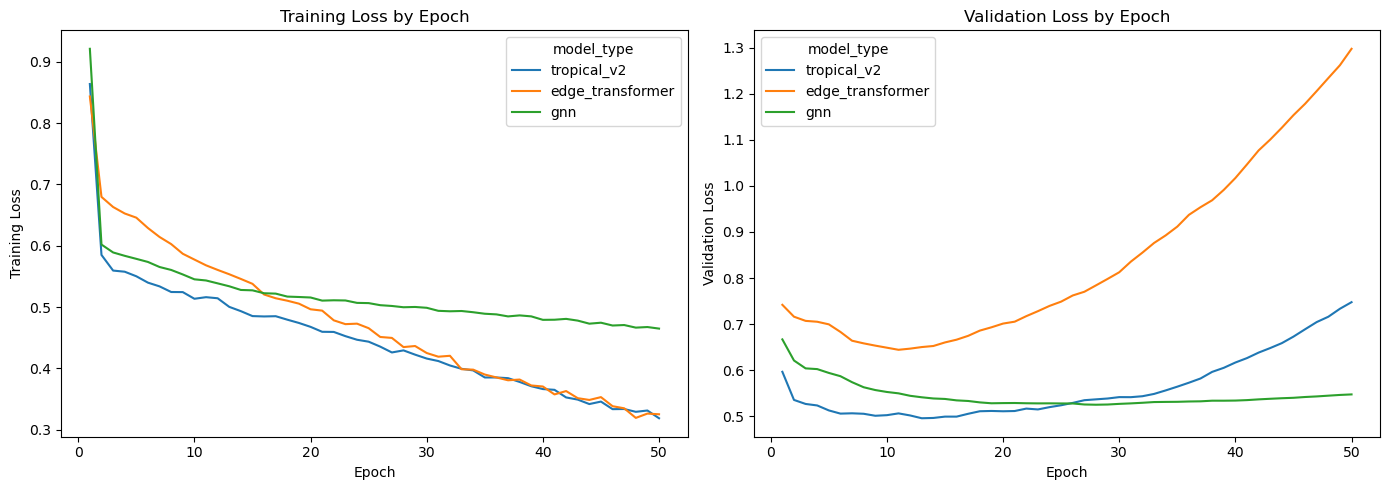

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.lineplot(
    data=df_all,
    x="epoch",
    y="train_loss",
    hue="model_type",
    ax=axes[0]
)

axes[0].set_title("Training Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="val_loss",
    hue="model_type",
    ax=axes[1]
)

axes[1].set_title("Validation Loss by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")

plt.tight_layout()
plt.show()

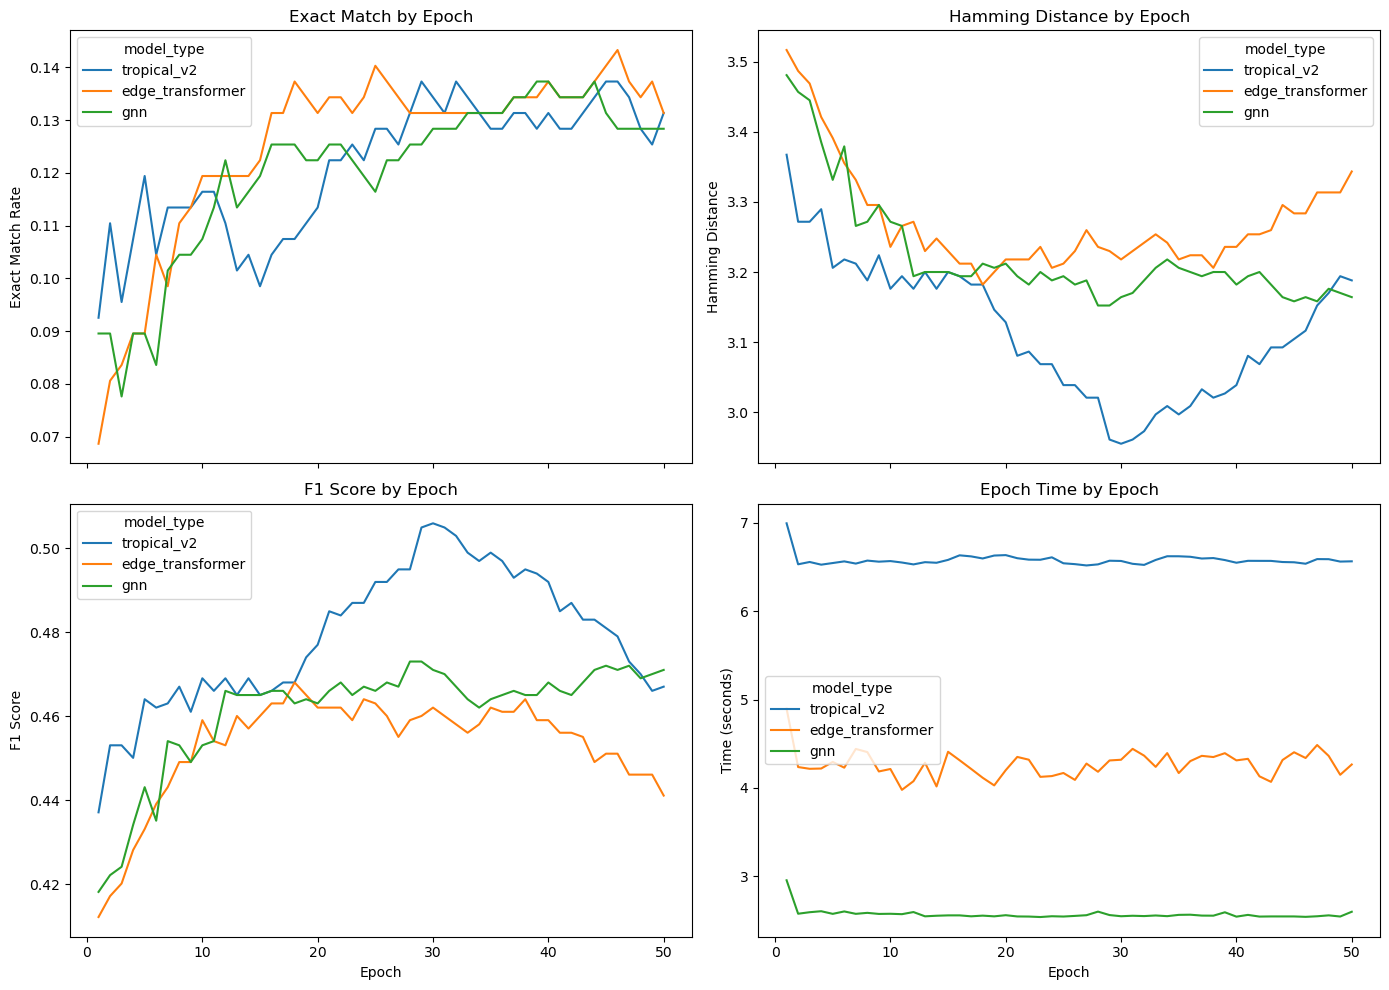

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

sns.lineplot(
    data=df_all,
    x="epoch",
    y="exact_match",
    hue="model_type",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Exact Match by Epoch")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Exact Match Rate")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="hamming",
    hue="model_type",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Hamming Distance by Epoch")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Hamming Distance")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="f1",
    hue="model_type",
    ax=axes[1, 0]
)
axes[1, 0].set_title("F1 Score by Epoch")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("F1 Score")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="epoch_time_seconds",
    hue="model_type",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Epoch Time by Epoch")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [103]:
df_tropical_eval = pd.read_csv('evaluation_results_tropical_shortest_path_ood_size_retrain_v2.csv')
df_tropical_eval.head()

,model_type,problem_type,eval_mode,wood_problem,network_name,graph_seed,n_nodes,n_edges,density,replication,...,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,tropical,shortest_path,ood_size,NaN,NaN,10020005,100,200,2.0,0,...,47,0.175439,2,0,0,1,1,0.197331,0.206144,0.177062
1,tropical,shortest_path,ood_size,NaN,NaN,10020006,100,200,2.0,1,...,14,0.222222,2,0,0,1,1,0.042843,0.049885,0.002416
2,tropical,shortest_path,ood_size,NaN,NaN,10020007,100,200,2.0,2,...,34,0.028571,2,0,0,1,1,0.045914,0.053108,0.002184
3,tropical,shortest_path,ood_size,NaN,NaN,10020008,100,200,2.0,3,...,29,0.236842,2,0,0,1,1,0.041570,0.048356,0.002125
4,tropical,shortest_path,ood_size,NaN,NaN,10020009,100,200,2.0,4,...,28,0.000000,0,1,1,1,1,0.042790,0.049962,0.002113


In [105]:
df_transformer_eval = pd.read_csv('evaluation_results_edge_transformer_shortest_path_ood_size_retrain_v2.csv')
df_transformer_eval.head() 

,model_type,problem_type,eval_mode,wood_problem,network_name,graph_seed,n_nodes,n_edges,density,replication,...,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,edge_transformer,shortest_path,ood_size,NaN,NaN,10020005,100,200,2.0,0,...,50,0.122807,2,0,0,1,1,0.166202,0.175091,0.174768
1,edge_transformer,shortest_path,ood_size,NaN,NaN,10020006,100,200,2.0,1,...,14,0.222222,2,0,0,1,1,0.043741,0.051034,0.002224
2,edge_transformer,shortest_path,ood_size,NaN,NaN,10020007,100,200,2.0,2,...,34,0.028571,2,0,0,1,1,0.045792,0.052876,0.001722
3,edge_transformer,shortest_path,ood_size,NaN,NaN,10020008,100,200,2.0,3,...,29,0.236842,2,0,0,1,1,0.042108,0.048892,0.001671
4,edge_transformer,shortest_path,ood_size,NaN,NaN,10020009,100,200,2.0,4,...,28,0.000000,0,1,1,1,1,0.043574,0.050699,0.001655


In [107]:
df_gnn_eval = pd.read_csv('evaluation_results_gnn_shortest_path_ood_size_retrain_v2.csv')
df_gnn_eval.head() 

,model_type,problem_type,eval_mode,wood_problem,network_name,graph_seed,n_nodes,n_edges,density,replication,...,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,gnn,shortest_path,ood_size,NaN,NaN,10020005,100,200,2.0,0,...,47,0.175439,2,0,0,1,1,0.165894,0.174785,0.180331
1,gnn,shortest_path,ood_size,NaN,NaN,10020006,100,200,2.0,1,...,14,0.222222,2,0,0,1,1,0.043337,0.050408,0.001109
2,gnn,shortest_path,ood_size,NaN,NaN,10020007,100,200,2.0,2,...,34,0.028571,2,0,0,1,1,0.052191,0.059776,0.001241
3,gnn,shortest_path,ood_size,NaN,NaN,10020008,100,200,2.0,3,...,29,0.236842,2,0,0,1,1,0.043246,0.051422,0.000917
4,gnn,shortest_path,ood_size,NaN,NaN,10020009,100,200,2.0,4,...,28,0.000000,0,1,1,1,1,0.043225,0.050516,0.000950


In [85]:
df_tropical_eval["model_type"] = "tropical"
df_transformer_eval["model_type"] = "edge_transformer"
df_gnn_eval["model_type"] = "gnn"

df_all_eval = pd.concat([df_tropical_eval, df_transformer_eval, df_gnn_eval], ignore_index=True)

df_all_eval.head()

,model_type,problem_type,eval_mode,wood_problem,network_name,graph_seed,n_nodes,n_edges,density,replication,...,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,tropical_v2,shortest_path,ood_size,NaN,NaN,10020005,100,200,2.0,0,...,47,0.175439,2,0,0,1,1,0.208230,0.216938,0.643044
1,tropical_v2,shortest_path,ood_size,NaN,NaN,10020006,100,200,2.0,1,...,14,0.222222,2,0,0,1,1,0.042651,0.050648,0.005748
2,tropical_v2,shortest_path,ood_size,NaN,NaN,10020007,100,200,2.0,2,...,34,0.028571,2,0,0,1,1,0.046526,0.053126,0.005449
3,tropical_v2,shortest_path,ood_size,NaN,NaN,10020008,100,200,2.0,3,...,29,0.236842,2,0,0,1,1,0.042390,0.048892,0.005289
4,tropical_v2,shortest_path,ood_size,NaN,NaN,10020009,100,200,2.0,4,...,28,0.000000,0,1,1,1,1,0.042025,0.049302,0.005332


In [87]:
summary = (
    df_all_eval.groupby(["model_type", "density"])
    .agg(
        count=("objective_gap", "count"),

        exact_match_avg=("exact_match", "mean"),
        exact_match_std=("exact_match", "std"),

        objective_gap_avg=("objective_gap", "mean"),
        objective_gap_median=("objective_gap", "median"),
        objective_gap_std=("objective_gap", "std"),

        hamming_distance_avg=("hamming_distance", "mean"),
        hamming_distance_std=("hamming_distance", "std"),

        inference_time_avg=("inference_time", "mean"),
        inference_time_std=("inference_time", "std"),

        mip_solve_time_avg=("mip_solve_time", "mean"),
        mip_solve_time_std=("mip_solve_time", "std"),
    )
    .reset_index()
)
summary

,model_type,density,count,exact_match_avg,exact_match_std,objective_gap_avg,objective_gap_median,objective_gap_std,hamming_distance_avg,hamming_distance_std,inference_time_avg,inference_time_std,mip_solve_time_avg,mip_solve_time_std
0,edge_transformer,2.0,400,0.0550,0.228266,0.151969,0.145044,0.103403,3.9075,2.150699,0.002316,0.008645,0.256252,0.319924
1,edge_transformer,2.5,400,0.0725,0.259639,0.150969,0.142857,0.107221,3.5800,2.023323,0.002078,0.000388,0.559518,0.950456
2,edge_transformer,3.0,400,0.0825,0.275470,0.145378,0.134848,0.110559,3.4575,2.030641,0.002320,0.000679,0.887617,1.341002
3,edge_transformer,4.0,400,0.0625,0.242365,0.157412,0.148148,0.114087,3.6725,2.156820,0.003055,0.001455,1.511507,1.980746
4,edge_transformer,5.0,400,0.1000,0.300376,0.142376,0.115385,0.129428,3.2225,1.888627,0.004123,0.002721,2.038709,2.743282
5,edge_transformer,6.0,400,0.0975,0.297009,0.141666,0.123106,0.119709,3.3350,1.983080,0.005307,0.003978,3.563599,4.489649
6,edge_transformer,8.0,400,0.0875,0.282920,0.147749,0.133333,0.128527,3.4625,2.121283,0.008490,0.006994,5.530336,6.441286
7,gnn,2.0,400,0.0775,0.267718,0.140437,0.127273,0.104165,3.7125,2.202720,0.001523,0.008963,0.256932,0.320404
8,gnn,2.5,400,0.0750,0.263721,0.152546,0.146341,0.112283,3.5550,2.035272,0.001110,0.000084,0.558480,0.947459
9,gnn,3.0,400,0.0825,0.275470,0.148836,0.134234,0.117709,3.4875,2.120397,0.001123,0.000080,0.888252,1.342195


In [89]:
def add_confidence_intervals(summary, metrics, confidence_multiplier=1.96):

    for metric in metrics:
        mean_col = f"{metric}_avg"
        std_col = f"{metric}_std"

        summary[f"{metric}_se"] = (summary[std_col] / np.sqrt(summary["count"]))

        summary[f"{metric}_ci_lower"] = (summary[mean_col] - confidence_multiplier * summary[f"{metric}_se"])

        summary[f"{metric}_ci_upper"] = (summary[mean_col] + confidence_multiplier * summary[f"{metric}_se"])

    return summary

In [91]:
metrics_for_ci = [
    "exact_match",
    "objective_gap",
    "hamming_distance",
    "inference_time",
    "mip_solve_time",
]

summary = add_confidence_intervals(summary, metrics_for_ci)

In [93]:
def plot_metric_with_ci(summary, metric, xlabel="Arc-to-Node Ratio (m/n)", ylabel=None, title=None):
    
    plt.figure(figsize=(9, 6))

    for model, group in summary.groupby("model_type"):
        group = group.sort_values("density")

        line, = plt.plot(
            group["density"],
            group[f"{metric}_avg"],
            marker="o",
            label=model)

        plt.plot(
            group["density"],
            group[f"{metric}_ci_lower"],
            linestyle="--",
            color=line.get_color(),
            alpha=0.6)

        plt.plot(
            group["density"],
            group[f"{metric}_ci_upper"],
            linestyle="--",
            color=line.get_color(),
            alpha=0.6)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title if title else f"{metric} by Network Density")
    plt.legend(title="Model")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

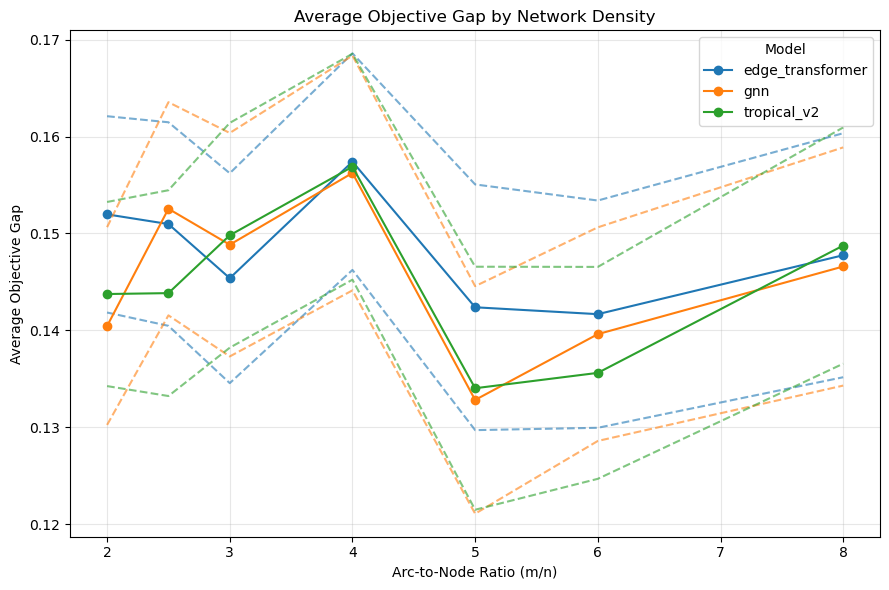

In [95]:
plot_metric_with_ci(
    summary,
    metric="objective_gap",
    ylabel="Average Objective Gap",
    title="Average Objective Gap by Network Density"
)

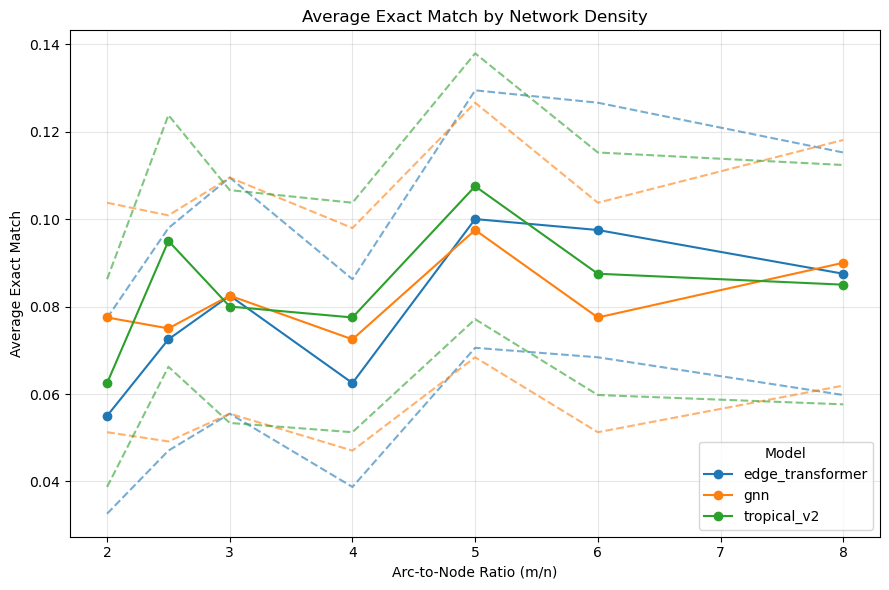

In [97]:
plot_metric_with_ci(
    summary,
    metric="exact_match",
    ylabel="Average Exact Match",
    title="Average Exact Match by Network Density"
)

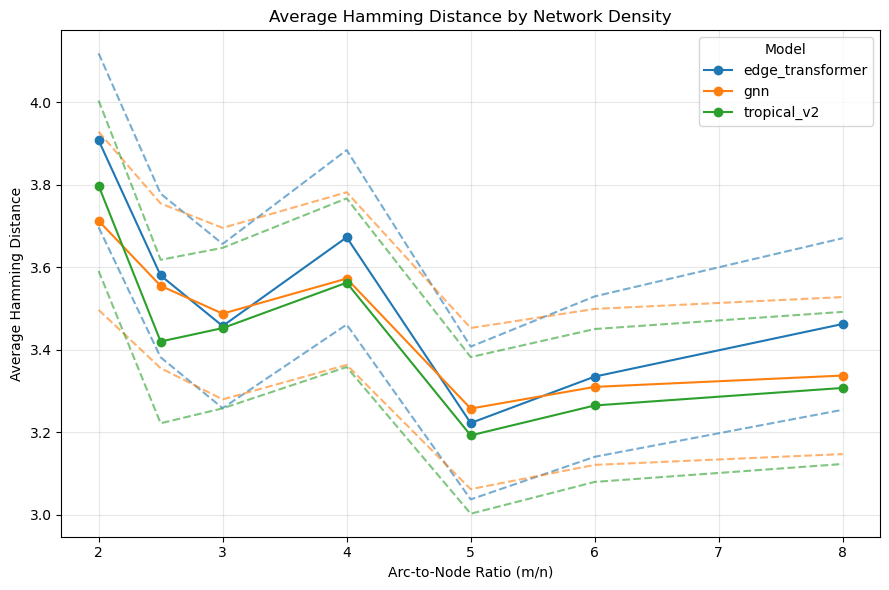

In [99]:
plot_metric_with_ci(
    summary,
    metric="hamming_distance",
    ylabel="Average Hamming Distance",
    title="Average Hamming Distance by Network Density"
)

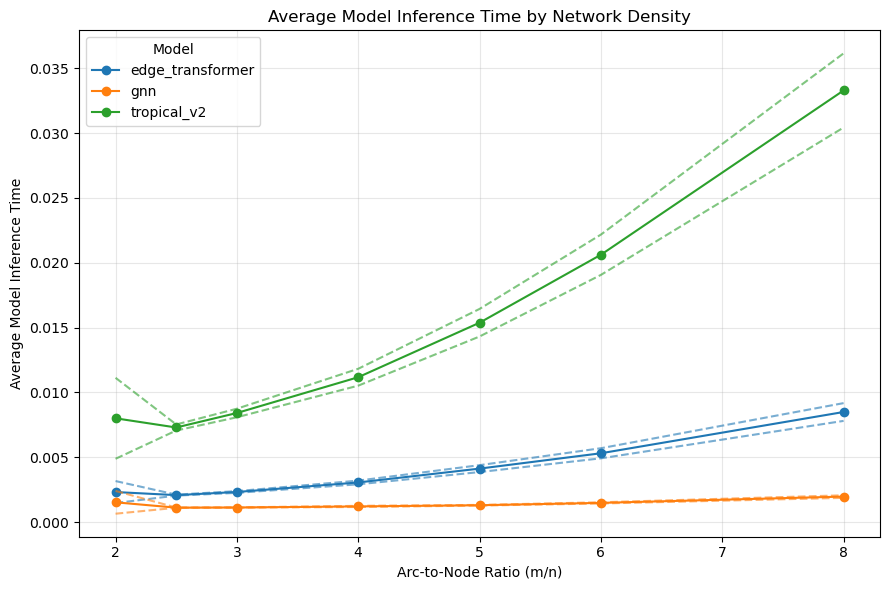

In [101]:
plot_metric_with_ci(
    summary,
    metric="inference_time",
    ylabel="Average Model Inference Time",
    title="Average Model Inference Time by Network Density"
)